In [2]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('geolocation.csv', 'geolocation'),
    ('order_items.csv', 'order_items'),
    ('orders.csv', 'orders'),
    ('payments.csv', 'payments'), 
    ('products.csv', 'products') ,
     ('sellers.csv', 'sellers') # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Coco@2020',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:\\Users\\KIIT0001\\OneDrive\\Desktop\\e-Commerce\\archive (1)'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing geolocation.csv
NaN values before replacement:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Processing order_items.csv
NaN values before replacement:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect(
    host='localhost',
    user='root',
    password='Coco@2020',
    database='ecommerce'
)
cursor=db.cursor()


List all unique cities where customers are located

In [5]:
query="""select distinct customer_city from customers"""
cursor.execute(query)
data=cursor.fetchall()
data
df=pd.DataFrame(data,columns=['customer_city'])
df.head(10)


,customer_city
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
5,jaragua do sul
6,timoteo
7,curitiba
8,belo horizonte
9,montes claros


Count the number of orders placed in 2017


In [6]:
query="""select  count(order_id) from orders where year(order_purchase_timestamp)=2017"""
cursor.execute(query)
data=cursor.fetchall()
"total  orders placed in 2017 are ",data[0][0]

('total  orders placed in 2017 are ', 135303)

Find the total sales per category

In [28]:
query = """
SELECT
    UPPER(products.product_category) AS product_category,
    ROUND(SUM(order_items.price), 2) AS total_sales
FROM products
JOIN order_items
    ON products.product_id = order_items.product_id
GROUP BY products.product_category
ORDER BY total_sales DESC;
"""
cursor.execute(query)
data=cursor.fetchall()

df=pd.DataFrame(data,columns=['product_category','total_sales'])
df.head(10)


,product_category,total_sales
0,HEALTH BEAUTY,11328132.07
1,WATCHES PRESENT,10845051.10
2,BED TABLE BATH,9332898.12
3,SPORT LEISURE,8892440.72
4,COMPUTER ACCESSORIES,8207588.86
5,FURNITURE DECORATION,6567862.43
6,COOL STUFF,5717617.67
7,HOUSEWARES,5690237.95
8,AUTOMOTIVE,5334481.00
9,GARDEN TOOLS,4367308.16


Calculate the percentaage of orders that were paid in installments

In [8]:
query="""select sum(case when payment_installments >= 1 then 1 else 0 end)/count(*)*100 as percentage from payments"""
cursor.execute(query)
data=cursor.fetchall()
"the percentage of orders that were paid in installments is ", data[0][0]


('the percentage of orders that were paid in installments is ',
 Decimal('99.9981'))

Count the number of customers from each city

In [9]:
query=""" select customer_city,count(customer_id) as total_customers from customers group by customer_city"""
cursor.execute(query)
data=cursor.fetchall()
data
df=pd.DataFrame(data,columns=['customer_city','total_customers'])
df 

,customer_city,total_customers
0,franca,644
1,sao bernardo do campo,3752
2,sao paulo,62160
3,mogi das cruzes,1532
4,campinas,5776
...,...,...
4114,siriji,4
4115,natividade da serra,4
4116,monte bonito,4
4117,sao rafael,4


Calculate the number of orders per month in 2018

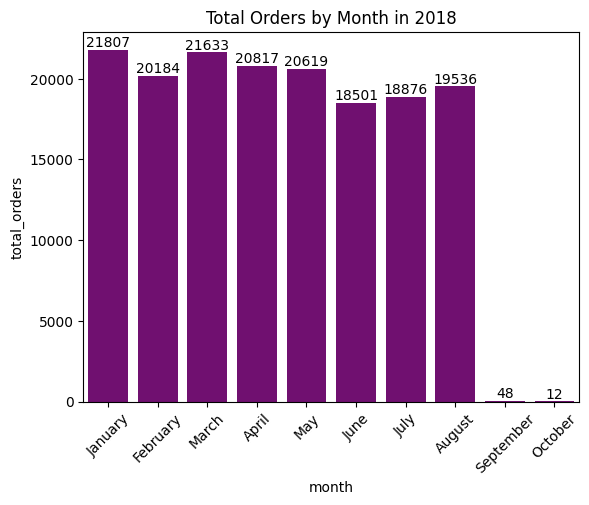

In [10]:
query="""select MONTHNAME(order_purchase_timestamp) as month, count(order_id) as total_orders from orders where year(order_purchase_timestamp)=2018 group by MONTHNAME(order_purchase_timestamp)"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data,columns=['month','total_orders'])
order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']
ax=sns.barplot(x=df['month'], y=df['total_orders'],order=order,color="purple")
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0])
plt.title('Total Orders by Month in 2018')
plt.show()



Find the average number of products per order , grouped by customer city

In [31]:
query = """
WITH count_per_order AS
(
    SELECT
        orders.order_id,
        orders.customer_id,
        COUNT(order_items.order_id) AS oc
    FROM orders
    JOIN order_items
        ON orders.order_id = order_items.order_id
    GROUP BY
        orders.order_id,
        orders.customer_id
)

SELECT
    customers.customer_city,
    ROUND(AVG(count_per_order.oc), 2) AS average_order
FROM customers
JOIN count_per_order
    ON customers.customer_id = count_per_order.customer_id
GROUP BY customers.customer_city
ORDER BY average_order DESC;
"""
cursor.execute(query)
data = cursor.fetchall()
df=pd.DataFrame(data, columns=['customer_city', 'average_order'])
df.head(10)

,customer_city,average_order
0,padre carvalho,63.00
1,celso ramos,58.50
2,datas,54.00
3,candido godoi,54.00
4,matias olimpio,45.00
5,cidelandia,36.00
6,curralinho,36.00
7,picarra,36.00
8,morro de sao paulo,36.00
9,teixeira soares,36.00


Calculate the percentage of total revenue contributed by each product category

In [27]:
query = """
SELECT
    UPPER(products.product_category) AS product_category,
    ROUND(
        (SUM(order_items.price) /
        (SELECT SUM(price) FROM order_items)) * 100,
        2
    ) AS percentage_sales
FROM products
JOIN order_items
    ON products.product_id = order_items.product_id
GROUP BY products.product_category
ORDER BY percentage_sales DESC;
"""

cursor.execute(query)
data = cursor.fetchall()

df = pd.DataFrame(data, columns=['product_category', 'percentage_sales'])
df.head(10)

,product_category,percentage_sales
0,HEALTH BEAUTY,27.78
1,WATCHES PRESENT,26.60
2,BED TABLE BATH,22.89
3,SPORT LEISURE,21.81
4,COMPUTER ACCESSORIES,20.13
5,FURNITURE DECORATION,16.11
6,COOL STUFF,14.02
7,HOUSEWARES,13.96
8,AUTOMOTIVE,13.08
9,GARDEN TOOLS,10.71


Calculate the total revenue generated by each seller, and rank them by revenue.

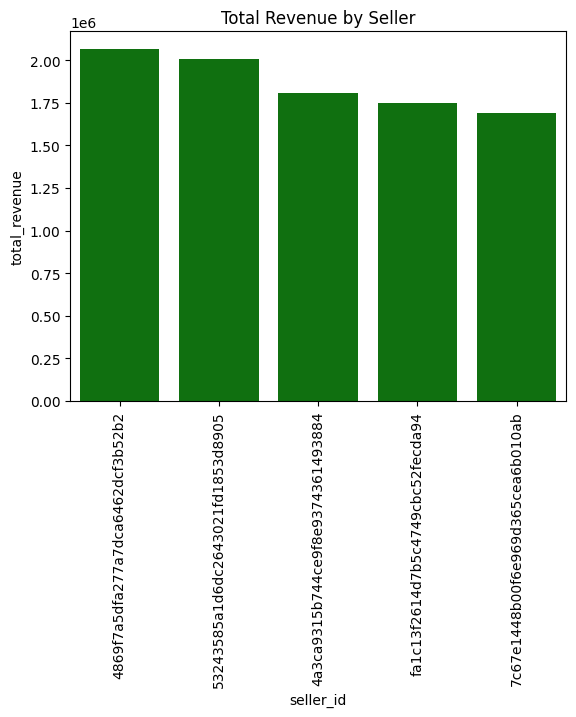

In [35]:
query = """
SELECT
    sellers.seller_id,
    ROUND(SUM(order_items.price), 2) AS total_revenue,
    RANK() OVER (ORDER BY SUM(order_items.price) DESC) AS seller_rank
FROM sellers
JOIN order_items
    ON sellers.seller_id = order_items.seller_id
GROUP BY sellers.seller_id
ORDER BY total_revenue DESC;
"""

cursor.execute(query)
data = cursor.fetchall()

df = pd.DataFrame(data, columns=['seller_id', 'total_revenue', 'seller_rank'])
df=df.head()
sns.barplot(x='seller_id', y='total_revenue', data=df, color="green")
plt.xticks(rotation=90)
plt.title('Total Revenue by Seller')
plt.show()

Calculate the cummulative sales per month for each year

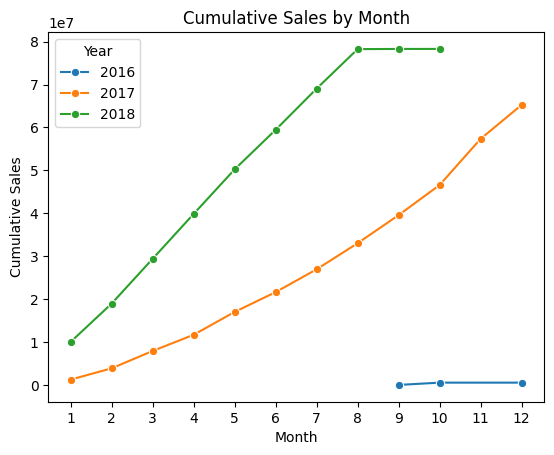

In [45]:
from turtle import color


query = """
WITH monthly_sales AS
(
    SELECT
        YEAR(orders.order_purchase_timestamp) AS year,
        MONTH(orders.order_purchase_timestamp) AS month,
        ROUND(SUM(payments.payment_value), 2) AS monthly_sales
    FROM orders
    JOIN payments
        ON orders.order_id = payments.order_id
    GROUP BY
        YEAR(orders.order_purchase_timestamp),
        MONTH(orders.order_purchase_timestamp)
)

SELECT
    year,
    month,
    monthly_sales,
    ROUND(
        SUM(monthly_sales) OVER (
            PARTITION BY year
            ORDER BY month
        ),
        2
    ) AS cumulative_sales
FROM monthly_sales
ORDER BY year, month;
"""

cursor.execute(query)
data = cursor.fetchall()

df = pd.DataFrame(
    data,
    columns=['year', 'month', 'monthly_sales', 'cumulative_sales']
)
sns.lineplot(x='month', y='cumulative_sales', hue='year', palette='tab10', data=df, marker='o')
plt.title('Cumulative Sales by Month')
plt.xlabel('Month')
plt.ylabel('Cumulative Sales')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.show()

Calculate the year-over-year growth rate of total sales

In [49]:
query = """
WITH yearly_sales AS
(
    SELECT
        YEAR(orders.order_purchase_timestamp) AS year,
        ROUND(SUM(payments.payment_value), 2) AS total_sales
    FROM orders
    JOIN payments
        ON orders.order_id = payments.order_id
    GROUP BY YEAR(orders.order_purchase_timestamp)
)

SELECT
    year,
    total_sales,
    LAG(total_sales) OVER(ORDER BY year) AS previous_year_sales,
    ROUND(
        (
            (total_sales - LAG(total_sales) OVER(ORDER BY year))
            / LAG(total_sales) OVER(ORDER BY year)
        ) * 100,
        2
    ) AS yoy_growth_percentage
FROM yearly_sales
ORDER BY year;
"""

cursor.execute(query)
data = cursor.fetchall()

df = pd.DataFrame(
    data,
    columns=[
        'year',
        'total_sales',
        'previous_year_sales',
        'yoy_growth_percentage'
    ]
)


Identify the top 3 customers who spent the most money in each year

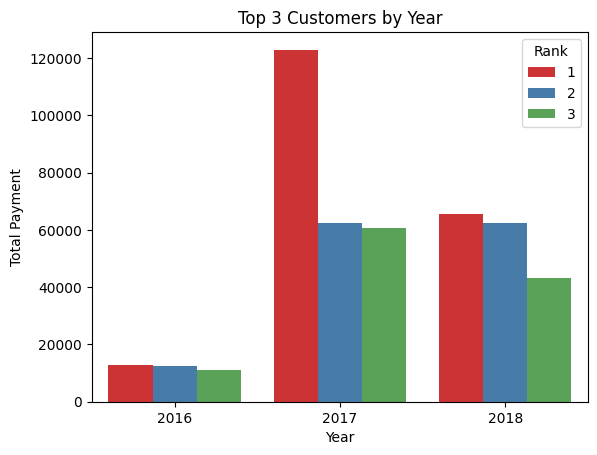

In [59]:
query="""select year,customer_id,payment,d_rank from
(select year(orders.order_purchase_timestamp) year,
 orders.customer_id,sum(payments.payment_value) payment,
 dense_rank() over (partition by year(orders.order_purchase_timestamp) order by sum(payments.payment_value) desc) d_rank
   from orders join 
   payments on orders.order_id=payments.order_id 
   group by year(orders.order_purchase_timestamp),
     orders.customer_id) as t where d_rank<=3;"""
cursor.execute(query)
data = cursor.fetchall()
df=pd.DataFrame(data, columns=['year', 'customer_id', 'payment', 'd_rank'])
sns.barplot(x='year', y='payment', hue='d_rank', data=df, palette='Set1')
plt.title('Top 3 Customers by Year')
plt.xlabel('Year')
plt.ylabel('Total Payment')
plt.legend(title='Rank')
plt.show()